## Cell 1 – Imports & Setup
Load all required libraries for data manipulation, visualization, modelling, and saving.

# 🏦 Banking Fraud Detection – End-to-End ML Pipeline
**Course:** Artificial Intelligence – VUIP111  
**Dataset:** banking_fraud_dataset_50k.csv (50,000 transactions)  
**Target Variable:** `is_fraud` (0 = Legitimate, 1 = Fraud)  
**Model:** Random Forest Classifier  

---
This notebook follows the project checklist step-by-step:
1. Imports & Setup
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Cleaning & Preprocessing
5. Feature Engineering
6. Train/Test Split
7. Model Training
8. Hyperparameter Tuning
9. Model Evaluation
10. Save Model for Deployment

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 – IMPORTS & SETUP
# Import every library needed for the full pipeline.
# pandas / numpy  → data manipulation
# matplotlib / seaborn → visualisation
# sklearn → ML algorithms, preprocessing, metrics
# joblib → saving and loading the trained model
# warnings → suppress non-critical warnings for cleaner output
# ─────────────────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.utils import resample

import joblib
import json
import os

# Set plot style globally
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries imported successfully.')
print(f'   pandas  {pd.__version__}  |  numpy  {np.__version__}')

✅ All libraries imported successfully.
   pandas  2.2.2  |  numpy  2.0.2


## Cell 2 – Load Dataset
Read the CSV file into a pandas DataFrame and take a first look at its shape and top rows.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 – LOAD DATASET
# Read the raw CSV from disk.
# pd.read_csv() loads the file into a DataFrame (tabular structure in memory).
# We immediately check shape (rows × columns) and peek at the first 5 rows
# to confirm the data loaded correctly before doing anything else.
# ─────────────────────────────────────────────────────────────────────────────

# ⚠️  Update this path if the CSV is in a different location
DATA_PATH = 'banking_fraud_dataset_50k.csv'

df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded → {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\nColumn names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Dataset loaded → 50,000 rows × 19 columns

Column names:
['transaction_id', 'customer_id', 'age', 'gender', 'city', 'account_type', 'transaction_date', 'transaction_type', 'merchant_category', 'amount', 'account_balance', 'transaction_hour', 'is_night_transaction', 'is_weekend', 'device_type', 'login_attempts', 'is_new_device', 'distance_from_home_km', 'is_fraud']

First 5 rows:


,transaction_id,customer_id,age,gender,city,account_type,transaction_date,transaction_type,merchant_category,amount,account_balance,transaction_hour,is_night_transaction,is_weekend,device_type,login_attempts,is_new_device,distance_from_home_km,is_fraud
0,TXN00000001,CUST007271,47,Male,Hyderabad,Credit,2022-09-05 12:03:00,UPI,Groceries,448.78,57951.27,12,0,0,Mobile,1,0,13.5,0
1,TXN00000002,CUST000861,20,Male,Hyderabad,Current,2022-05-17 21:09:00,Net Banking,Shopping,1760.93,64236.34,21,0,0,Mobile,1,0,36.3,0
2,TXN00000003,CUST005391,31,Female,Kolkata,Savings,2023-01-19 00:55:00,UPI,Education,975.44,132056.07,0,1,0,Mobile,1,1,4.4,0
3,TXN00000004,CUST013419,28,Female,Chennai,Credit,2023-05-03 11:54:00,UPI,Healthcare,147194.88,108438.48,11,0,0,POS,1,0,67.4,0
4,TXN00000005,CUST005192,57,Male,Delhi,Savings,2023-10-30 17:49:00,UPI,Education,5938.80,75727.48,17,0,0,Mobile,1,1,43.7,0


## Cell 3 – Exploratory Data Analysis (EDA)
Understand the data distribution, class balance, data types, and statistical summaries.

=== Data Types ===
transaction_id            object
customer_id               object
age                        int64
gender                    object
city                      object
account_type              object
transaction_date          object
transaction_type          object
merchant_category         object
amount                   float64
account_balance          float64
transaction_hour           int64
is_night_transaction       int64
is_weekend                 int64
device_type               object
login_attempts             int64
is_new_device              int64
distance_from_home_km    float64
is_fraud                   int64
dtype: object

=== Statistical Summary ===


,age,amount,account_balance,transaction_hour,is_night_transaction,is_weekend,login_attempts,is_new_device,distance_from_home_km,is_fraud
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,46.036660,17083.536713,100231.415018,11.480360,0.33674,0.287320,1.547100,0.149200,20.110324,0.035000
std,16.460547,67899.315220,57734.412515,6.937995,0.47260,0.452517,1.002298,0.356289,20.158747,0.183782
min,18.000000,10.000000,501.210000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,32.000000,917.455000,50432.602500,5.000000,0.00000,0.000000,1.000000,0.000000,5.700000,0.000000
50%,46.000000,2228.785000,100077.695000,11.000000,0.00000,0.000000,1.000000,0.000000,13.900000,0.000000
75%,60.000000,4673.285000,150033.357500,18.000000,1.00000,1.000000,2.000000,0.000000,27.900000,0.000000
max,74.000000,499703.450000,199993.560000,23.000000,1.00000,1.000000,5.000000,1.000000,225.000000,1.000000



=== Missing Values per Column ===
✅ No missing values found.

=== Target Class Distribution ===
          Count  Percentage (%)
is_fraud                       
0         48250            96.5
1          1750             3.5


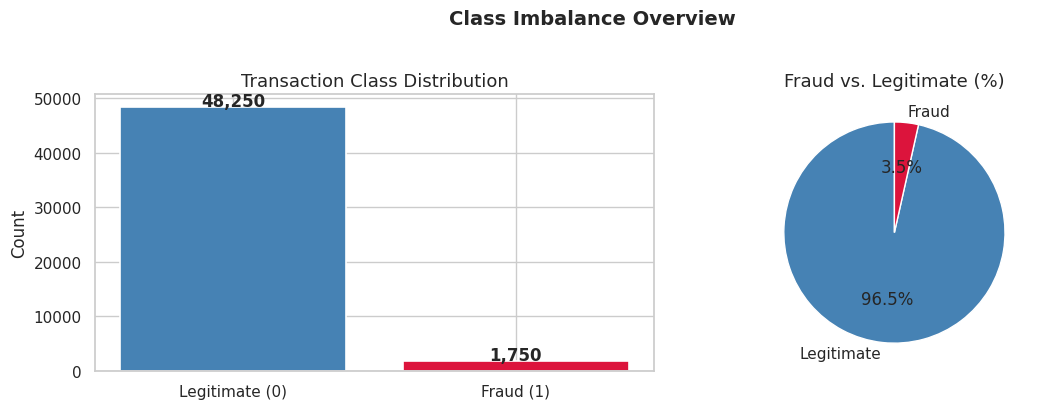

⚠️  Dataset is heavily imbalanced – we will handle this during preprocessing.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 – EXPLORATORY DATA ANALYSIS (EDA)
# Before modelling we must *understand* the data:
#   • dtypes  → what kind of values each column holds
#   • describe() → basic statistics (mean, std, min, max, quartiles)
#   • isnull() → locate missing values
#   • value_counts() → class distribution (fraud vs. legit)
# We also plot the class imbalance so it is clearly visible.
# ─────────────────────────────────────────────────────────────────────────────

# ── 3a. Data types ────────────────────────────────────────────────────────────
print('=== Data Types ===')
print(df.dtypes)

# ── 3b. Basic statistics ──────────────────────────────────────────────────────
print('\n=== Statistical Summary ===')
display(df.describe())

# ── 3c. Missing values ────────────────────────────────────────────────────────
print('\n=== Missing Values per Column ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '✅ No missing values found.')

# ── 3d. Class distribution ────────────────────────────────────────────────────
fraud_counts = df['is_fraud'].value_counts()
fraud_pct    = df['is_fraud'].value_counts(normalize=True) * 100
print('\n=== Target Class Distribution ===')
print(pd.DataFrame({'Count': fraud_counts, 'Percentage (%)': fraud_pct.round(2)}))

# ── 3e. Plot class imbalance ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts.values,
            color=['steelblue', 'crimson'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Transaction Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.1f%%', colors=['steelblue', 'crimson'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Fraud vs. Legitimate (%)', fontsize=13)

plt.suptitle('Class Imbalance Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠️  Dataset is heavily imbalanced – we will handle this during preprocessing.')

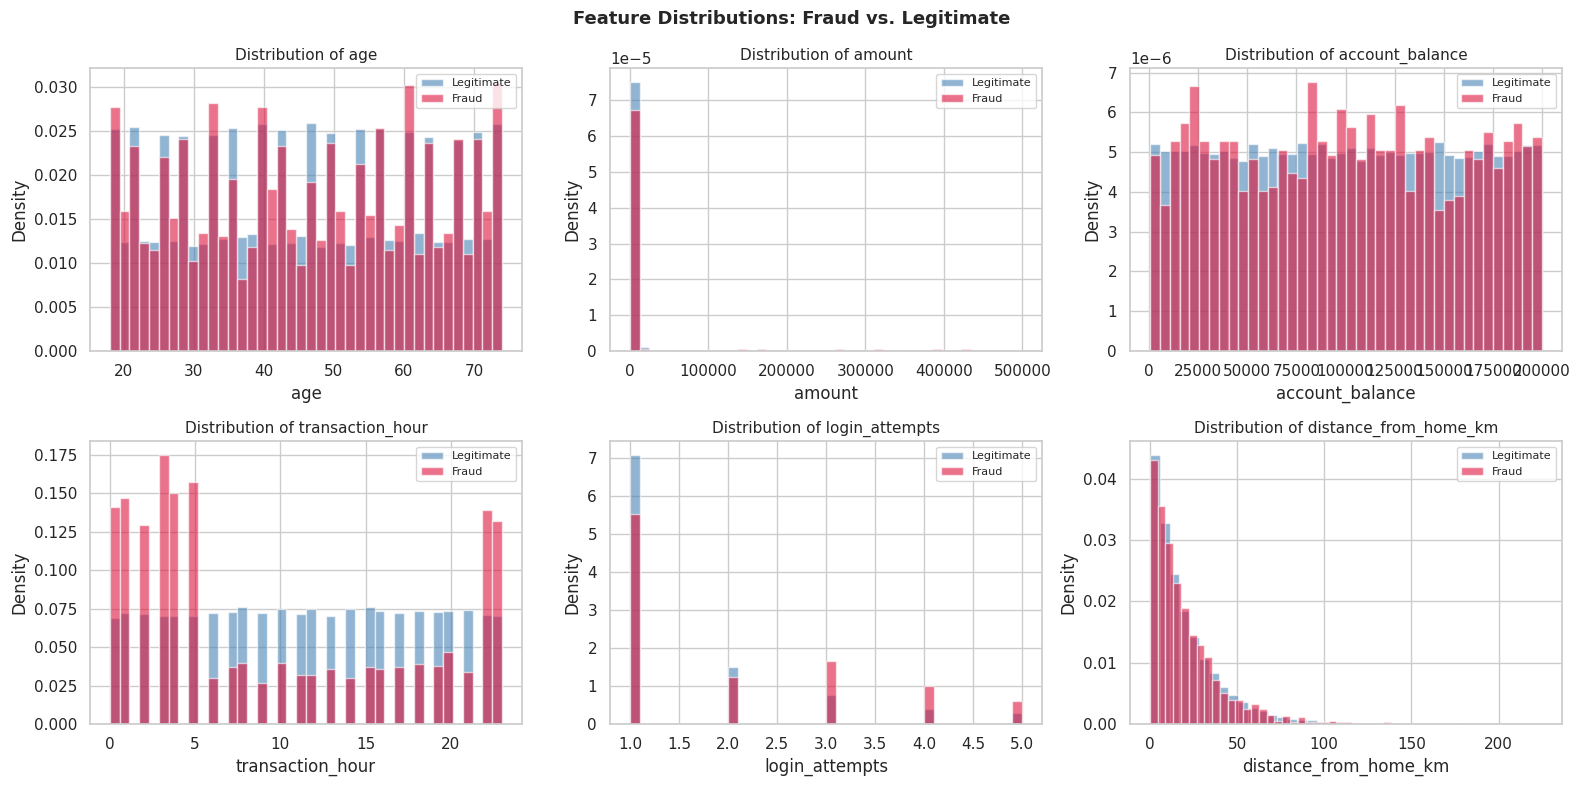

✅ Feature distribution plots generated.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3b – EDA: Feature Distributions
# Plot histograms for key numeric features to spot skew, outliers,
# or unusual patterns that may affect model training.
# ─────────────────────────────────────────────────────────────────────────────

numeric_cols = ['age', 'amount', 'account_balance', 'transaction_hour',
                'login_attempts', 'distance_from_home_km']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Separate fraud vs non-fraud distributions
    axes[i].hist(df[df['is_fraud'] == 0][col], bins=40, alpha=0.6,
                 color='steelblue', label='Legitimate', density=True)
    axes[i].hist(df[df['is_fraud'] == 1][col], bins=40, alpha=0.6,
                 color='crimson', label='Fraud', density=True)
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Fraud vs. Legitimate', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature distribution plots generated.')

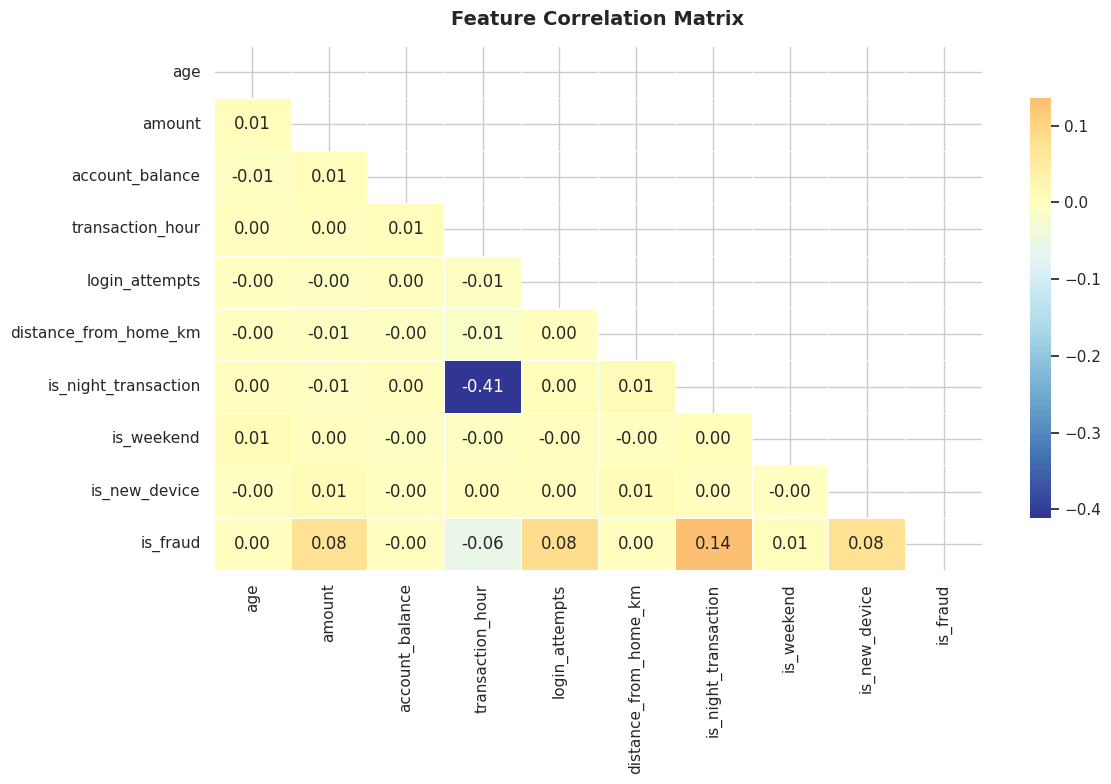

✅ Correlation heatmap generated.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3c – EDA: Correlation Heatmap
# A correlation matrix shows how strongly pairs of numeric features
# are related. Values close to +1 or -1 indicate strong relationships.
# This helps us spot redundant features and understand predictors of fraud.
# ─────────────────────────────────────────────────────────────────────────────

corr_cols = numeric_cols + ['is_night_transaction', 'is_weekend',
                             'is_new_device', 'is_fraud']

plt.figure(figsize=(12, 8))
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show only lower triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation heatmap generated.')

## Cell 4 – Data Cleaning & Preprocessing
Handle missing values, drop irrelevant columns, and encode categorical features.

In [ ]:
# ── Step A: Convert transaction_date to datetime BEFORE dropping ──────────────
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Drop non-predictive columns
drop_cols = ['transaction_id', 'customer_id', 'city']
df_clean = df.drop(columns=drop_cols)
print(f'Dropped columns: {drop_cols}')
print(f'Remaining columns: {df_clean.shape[1]}')

# ── Step B: Handle missing values ────────────────────────────────────────────
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f'  Filled {col} (numeric) with median')
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            print(f'  Filled {col} (categorical) with mode')
print('✅ Missing value handling complete.')

# ── Step C: Label-encode categorical columns ──────────────────────────────────
# Exclude datetime columns AND transaction_date from encoding
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f'  Encoded "{col}" → {list(le.classes_)}')

print(f'\n✅ Encoded {len(cat_cols)} categorical column(s).')
print(f'Dataset shape after cleaning: {df_clean.shape}')

Dropped columns: ['transaction_id', 'customer_id', 'city']
Remaining columns: 16
✅ Missing value handling complete.
  Encoded "gender" → ['Female', 'Male']
  Encoded "account_type" → ['Credit', 'Current', 'Savings']
  Encoded "transaction_type" → ['ATM', 'Card', 'IMPS', 'NEFT', 'Net Banking', 'UPI']
  Encoded "merchant_category" → ['Dining', 'Education', 'Electronics', 'Entertainment', 'Fuel', 'Groceries', 'Healthcare', 'Shopping', 'Travel', 'Utilities']
  Encoded "device_type" → ['ATM', 'Desktop', 'Mobile', 'POS']

✅ Encoded 5 categorical column(s).
Dataset shape after cleaning: (50000, 16)


## Cell 5 – Feature Engineering
Create new meaningful features from existing columns to give the model more signal.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 – FEATURE ENGINEERING
# Raw features are often not the best representation of the underlying signal.
# We derive new features that capture domain-specific fraud patterns:
#
#  • amount_to_balance_ratio → large transactions relative to balance are risky
#  • transaction_day, transaction_month, day_of_week → temporal patterns
#  • high_amount_flag → binary flag for unusually large transactions (top 5%)
#  • multi_login_flag  → multiple failed logins before transaction = suspicious
#
# After creating derived features we drop the raw 'transaction_date' column
# as its information has been extracted.
# ─────────────────────────────────────────────────────────────────────────────

# ── 5a. Amount-to-balance ratio ───────────────────────────────────────────────
# Avoid division by zero: replace 0 balance with a tiny positive value
df_clean['amount_to_balance_ratio'] = (
    df_clean['amount'] / df_clean['account_balance'].replace(0, 0.01)
)

# ── 5b. Date-based temporal features ─────────────────────────────────────────
df_clean['transaction_day']   = df_clean['transaction_date'].dt.day
df_clean['transaction_month'] = df_clean['transaction_date'].dt.month
df_clean['day_of_week']       = df_clean['transaction_date'].dt.dayofweek  # 0=Mon … 6=Sun

# ── 5c. Binary flag for unusually large transactions ─────────────────────────
high_amount_threshold = df_clean['amount'].quantile(0.95)
df_clean['high_amount_flag'] = (df_clean['amount'] > high_amount_threshold).astype(int)
print(f'High-amount threshold (95th percentile): {high_amount_threshold:,.2f}')

# ── 5d. Multiple login-attempts flag ─────────────────────────────────────────
df_clean['multi_login_flag'] = (df_clean['login_attempts'] > 1).astype(int)

# ── 5e. Drop raw date column (information already extracted) ──────────────────
df_clean.drop(columns=['transaction_date'], inplace=True)

print(f'\n✅ Feature engineering complete.')
print(f'New features added: amount_to_balance_ratio, transaction_day,')
print(f'                    transaction_month, day_of_week, high_amount_flag, multi_login_flag')
print(f'Final dataset shape: {df_clean.shape}')
df_clean.head(3)

High-amount threshold (95th percentile): 55,151.00

✅ Feature engineering complete.
New features added: amount_to_balance_ratio, transaction_day,
                    transaction_month, day_of_week, high_amount_flag, multi_login_flag
Final dataset shape: (50000, 21)


,age,gender,account_type,transaction_type,merchant_category,amount,account_balance,transaction_hour,is_night_transaction,is_weekend,...,login_attempts,is_new_device,distance_from_home_km,is_fraud,amount_to_balance_ratio,transaction_day,transaction_month,day_of_week,high_amount_flag,multi_login_flag
0,47,1,0,5,5,448.78,57951.27,12,0,0,...,1,0,13.5,0,0.007744,5,9,0,0,0
1,20,1,1,4,7,1760.93,64236.34,21,0,0,...,1,0,36.3,0,0.027413,17,5,1,0,0
2,31,0,2,5,1,975.44,132056.07,0,1,0,...,1,1,4.4,0,0.007387,19,1,3,0,0


## Cell 6 – Handle Class Imbalance & Train/Test Split
The dataset has ~3.5% fraud. We upsample the minority class to prevent the model from simply predicting 'not fraud' for everything.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 – HANDLE CLASS IMBALANCE & TRAIN / TEST SPLIT
#
# Problem: only ~3.5% of transactions are fraud → a model that always predicts
# 'not fraud' gets 96.5% accuracy but is useless.
#
# Solution – Oversampling (SMOTE-style manual approach):
#   • We duplicate (resample with replacement) the minority (fraud) class rows
#     in the TRAINING set until it matches the majority class.
#   • The TEST set is never resampled (it must reflect real-world distribution).
#
# Train/Test split: 80% train – 20% test using stratify=is_fraud to ensure
# both splits have the same fraud ratio before balancing the training set.
# ─────────────────────────────────────────────────────────────────────────────

# ── Define features (X) and target (y) ───────────────────────────────────────
X = df_clean.drop(columns=['is_fraud'])
y = df_clean['is_fraud']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Feature columns: {X.columns.tolist()}')

# ── Train / Test split (80 / 20, stratified) ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'\nTrain size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Fraud in train: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'Fraud in test : {y_test.sum():,}  ({y_test.mean()*100:.1f}%)')

# ── Oversample minority class in TRAINING set only ───────────────────────────
train_data = pd.concat([X_train, y_train], axis=1)

majority = train_data[train_data['is_fraud'] == 0]
minority = train_data[train_data['is_fraud'] == 1]

minority_upsampled = resample(
    minority,
    replace=True,                  # sample with replacement
    n_samples=len(majority),       # match majority class size
    random_state=42
)

train_balanced = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42)

X_train_bal = train_balanced.drop(columns=['is_fraud'])
y_train_bal = train_balanced['is_fraud']

print(f'\nAfter balancing:')
print(f'  Legit : {(y_train_bal == 0).sum():,}')
print(f'  Fraud : {(y_train_bal == 1).sum():,}')
print('✅ Class imbalance handled. Test set remains untouched.')

Features shape : (50000, 20)
Target shape   : (50000,)
Feature columns: ['age', 'gender', 'account_type', 'transaction_type', 'merchant_category', 'amount', 'account_balance', 'transaction_hour', 'is_night_transaction', 'is_weekend', 'device_type', 'login_attempts', 'is_new_device', 'distance_from_home_km', 'amount_to_balance_ratio', 'transaction_day', 'transaction_month', 'day_of_week', 'high_amount_flag', 'multi_login_flag']

Train size: 40,000 | Test size: 10,000
Fraud in train: 1,400 (3.5%)
Fraud in test : 350  (3.5%)

After balancing:
  Legit : 38,600
  Fraud : 38,600
✅ Class imbalance handled. Test set remains untouched.


## Cell 7 – Feature Scaling
Normalise numeric features so no single feature dominates due to scale differences.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 – FEATURE SCALING
# StandardScaler converts each feature to zero mean and unit variance:
#   z = (x − mean) / std
# This prevents features like 'amount' (large values) from dominating
# 'login_attempts' (small values).
#
# IMPORTANT: fit scaler ONLY on training data, then transform both
# train and test sets. Fitting on the test set would cause data leakage.
# ─────────────────────────────────────────────────────────────────────────────

scaler = StandardScaler()

# Columns to scale (all numeric feature columns)
scale_cols = X_train_bal.columns.tolist()

X_train_scaled = scaler.fit_transform(X_train_bal)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)            # only transform on test (no leakage)

# Convert back to DataFrames for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=scale_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=scale_cols)

print(f'Scaler fitted on {X_train_bal.shape[0]:,} training samples.')
print(f'Features scaled: {len(scale_cols)}')
print('✅ Feature scaling complete (fit on train, transform on test).')
print(f'\nSample scaled values (first row):')
print(X_train_scaled.iloc[0].round(4))

Scaler fitted on 77,200 training samples.
Features scaled: 20
✅ Feature scaling complete (fit on train, transform on test).

Sample scaled values (first row):
age                       -0.0676
gender                     0.9681
account_type              -0.2489
transaction_type          -1.0520
merchant_category         -1.2275
amount                    -0.3224
account_balance            1.2548
transaction_hour          -1.3763
is_night_transaction       1.0008
is_weekend                -0.6452
device_type               -1.8009
login_attempts            -0.6509
is_new_device             -0.5347
distance_from_home_km      1.8089
amount_to_balance_ratio   -0.1460
transaction_day           -1.1244
transaction_month          0.1393
day_of_week               -0.0038
high_amount_flag          -0.3348
multi_login_flag          -0.7682
Name: 0, dtype: float64


## Cell 8 – Model Training (Random Forest)
Train a Random Forest Classifier – an ensemble of decision trees that is robust, interpretable, and handles imbalanced data well.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 – MODEL TRAINING
# Random Forest builds multiple decision trees on random subsets of data
# and features (bootstrap + feature bagging), then combines predictions
# by majority vote. Benefits:
#   • Handles non-linear patterns
#   • Robust to outliers
#   • Provides feature importances
#   • Less likely to overfit than a single decision tree
#
# n_estimators=100 → build 100 trees (balance of speed vs accuracy)
# class_weight='balanced' → additional weight to minority class (fraud)
# random_state=42 → reproducibility
# ─────────────────────────────────────────────────────────────────────────────

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1           # use all CPU cores for faster training
)

print('Training Random Forest on balanced training set...')
rf_model.fit(X_train_scaled, y_train_bal)

print('✅ Model training complete!')
print(f'   Trees trained : {rf_model.n_estimators}')
print(f'   Features used : {rf_model.n_features_in_}')

# Quick cross-validation on training set to check generalisation
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train_bal,
                             cv=5, scoring='f1', n_jobs=-1)
print(f'\n5-Fold CV F1 scores: {cv_scores.round(4)}')
print(f'Mean CV F1 : {cv_scores.mean():.4f}  (±{cv_scores.std():.4f})')

Training Random Forest on balanced training set...
✅ Model training complete!
   Trees trained : 100
   Features used : 20

5-Fold CV F1 scores: [1.     1.     0.9998 0.9999 0.9997]
Mean CV F1 : 0.9999  (±0.0001)


## Cell 9 – Hyperparameter Tuning
Use GridSearchCV to find the best combination of model parameters automatically.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
print("Imports done!")

Imports done!


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 – HYPERPARAMETER TUNING (GridSearchCV)
# GridSearchCV exhaustively tests every combination of the given parameters
# using k-fold cross-validation, then returns the combination with the
# highest score on the chosen metric (F1, because of imbalance).
#
# We use a smaller grid to keep runtime reasonable.
# Increase cv or add more values for thorough tuning.
# ─────────────────────────────────────────────────────────────────────────────

param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 15, 25],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2']
}

print('Running GridSearchCV (this may take a few minutes)...')
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train_bal)

print(f'\n✅ Best parameters found:')
for k, v in grid_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\nBest CV F1 score: {grid_search.best_score_:.4f}')

# Use the best model for all further evaluation
best_model = grid_search.best_estimator_
print('\nbest_model is now the tuned Random Forest.')

Running GridSearchCV (this may take a few minutes)...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ Best parameters found:
   max_depth: None
   max_features: sqrt
   min_samples_split: 5
   n_estimators: 200

Best CV F1 score: 0.9999

best_model is now the tuned Random Forest.


## Cell 10 – Model Evaluation
Evaluate the best model on the held-out test set using multiple metrics.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 – MODEL EVALUATION
# We evaluate on the RAW test set (not resampled) to reflect real-world performance.
#
# Key metrics for fraud detection (imbalanced problem):
#  • Accuracy   → overall correct predictions (misleading when imbalanced)
#  • Precision  → of predicted frauds, how many are real frauds
#  • Recall     → of real frauds, how many did we catch (very important!)
#  • F1-Score   → harmonic mean of precision and recall
#  • ROC-AUC    → area under ROC curve, model's discrimination ability
#
# Confusion matrix shows:
#   TP = correctly identified fraud
#   FP = falsely flagged legitimate (customer inconvenience)
#   FN = missed fraud (worst outcome – financial loss)
#   TN = correctly cleared legitimate
# ─────────────────────────────────────────────────────────────────────────────

y_pred      = best_model.predict(X_test_scaled)
y_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1]

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print('=' * 45)
print('       MODEL EVALUATION RESULTS')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('=' * 45)
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

       MODEL EVALUATION RESULTS
  Accuracy  : 0.9650  (96.50%)
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  ROC-AUC   : 0.7696

Full Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      1.00      0.98      9650
       Fraud       0.00      0.00      0.00       350

    accuracy                           0.96     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.93      0.96      0.95     10000



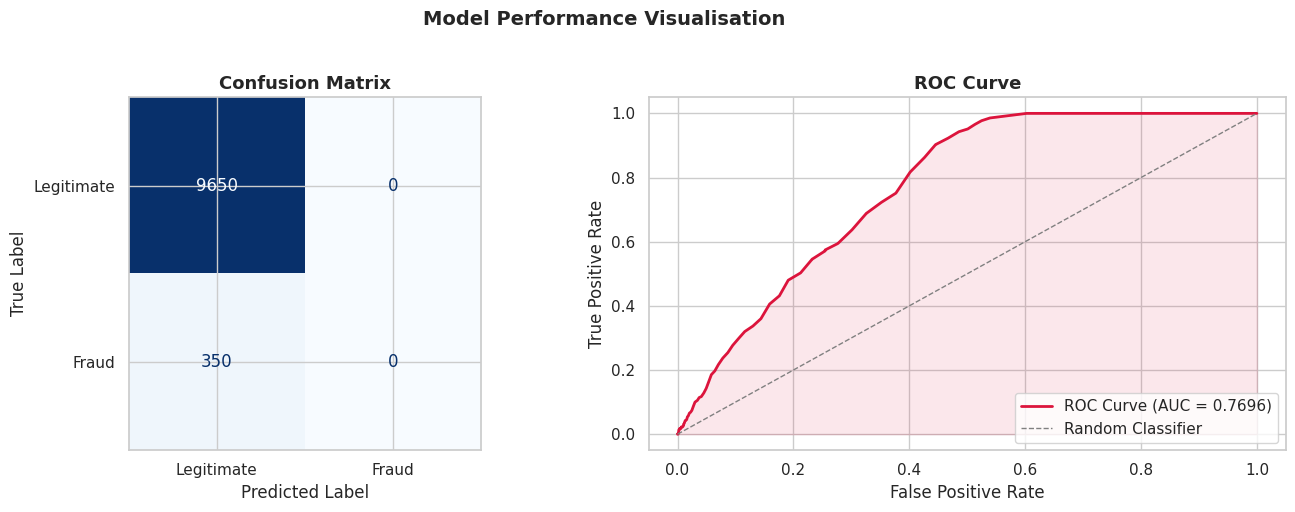

✅ Evaluation plots saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10b – CONFUSION MATRIX & ROC CURVE PLOTS
# Visual representations of model performance:
#  Left  → Confusion matrix (actual vs predicted counts)
#  Right → ROC curve (TPR vs FPR at different thresholds)
#          Higher AUC = better discrimination between fraud and legitimate
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ── ROC Curve ────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='crimson', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='crimson')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.suptitle('Model Performance Visualisation', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Evaluation plots saved.')

Feature Importances (Top 10):
                Feature  Importance
       transaction_hour    0.097760
                 amount    0.096566
   is_night_transaction    0.092317
amount_to_balance_ratio    0.082127
        account_balance    0.074990
  distance_from_home_km    0.073011
                    age    0.063956
         login_attempts    0.063401
        transaction_day    0.059009
          is_new_device    0.055406


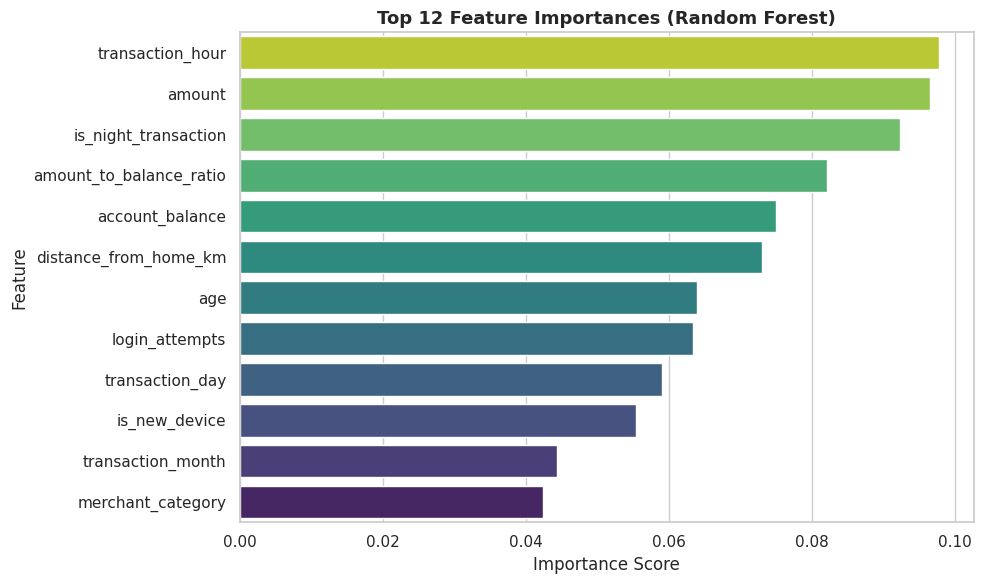

✅ Feature importance plot saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10c – FEATURE IMPORTANCE
# Random Forests compute how much each feature reduces impurity (Gini) across
# all trees. Features with higher importance are stronger predictors of fraud.
# This helps us understand WHAT the model is looking at.
# ─────────────────────────────────────────────────────────────────────────────

importances = best_model.feature_importances_
feat_names  = X_train_bal.columns
feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})\
               .sort_values('Importance', ascending=False).reset_index(drop=True)

print('Feature Importances (Top 10):')
print(feat_imp_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(12), x='Importance', y='Feature',
            palette='viridis_r', edgecolor='white')
plt.title('Top 12 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance plot saved.')

## Cell 11 – Save Model & Artefacts for Deployment
Persist the trained model, scaler, encoder mapping, and feature list so they can be loaded in a backend API for real-time predictions.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 – SAVE MODEL & DEPLOYMENT ARTEFACTS
#
# joblib.dump() serialises Python objects to disk.
# We save:
#   • best_model.pkl      → trained Random Forest
#   • scaler.pkl          → fitted StandardScaler (must apply same transform at inference)
#   • label_encoders.pkl  → LabelEncoder objects for categorical cols
#   • model_metadata.json → human-readable info about the model & features
#
# At inference time, load these artefacts and apply the same
# preprocessing steps to new input before calling model.predict().
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs('model_artefacts', exist_ok=True)

# Save model
joblib.dump(best_model, 'model_artefacts/best_model.pkl')
print('✅ Saved: model_artefacts/best_model.pkl')

# Save scaler
joblib.dump(scaler, 'model_artefacts/scaler.pkl')
print('✅ Saved: model_artefacts/scaler.pkl')

# Save label encoders
joblib.dump(label_encoders, 'model_artefacts/label_encoders.pkl')
print('✅ Saved: model_artefacts/label_encoders.pkl')

# Save feature list and metadata
metadata = {
    'model_type'        : 'RandomForestClassifier',
    'best_params'       : grid_search.best_params_,
    'feature_columns'   : X_train_bal.columns.tolist(),
    'categorical_cols'  : cat_cols,
    'target_column'     : 'is_fraud',
    'performance': {
        'accuracy' : round(acc, 4),
        'precision': round(precision, 4),
        'recall'   : round(recall, 4),
        'f1_score' : round(f1, 4),
        'roc_auc'  : round(roc_auc, 4)
    }
}

with open('model_artefacts/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print('✅ Saved: model_artefacts/model_metadata.json')

print('\n=== Final Saved Model Performance ===')
for k, v in metadata['performance'].items():
    print(f'  {k:10s}: {v}')
print('\n🎉 All artefacts saved. Model is ready for deployment!')

✅ Saved: model_artefacts/best_model.pkl
✅ Saved: model_artefacts/scaler.pkl
✅ Saved: model_artefacts/label_encoders.pkl
✅ Saved: model_artefacts/model_metadata.json

=== Final Saved Model Performance ===
  accuracy  : 0.965
  precision : 0.0
  recall    : 0.0
  f1_score  : 0.0
  roc_auc   : 0.7696

🎉 All artefacts saved. Model is ready for deployment!


In [ ]:
!pip install gradio joblib scikit-learn pandas numpy

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Banking Fraud Detection – Gradio Frontend
# Course: Artificial Intelligence – VUIP111
#
# HOW TO RUN:
#   1. Make sure model_artefacts/ folder is in the same directory as this file
#      (best_model.pkl, scaler.pkl, label_encoders.pkl, model_metadata.json)
#   2. pip install gradio joblib scikit-learn pandas numpy
#   3. python app.py
# ─────────────────────────────────────────────────────────────────────────────

import gradio as gr
import joblib
import json
import numpy as np
import pandas as pd
from datetime import datetime

# ── Load model artefacts ──────────────────────────────────────────────────────
print("Loading model artefacts...")
model          = joblib.load("model_artefacts/best_model.pkl")
scaler         = joblib.load("model_artefacts/scaler.pkl")
label_encoders = joblib.load("model_artefacts/label_encoders.pkl")

with open("model_artefacts/model_metadata.json") as f:
    metadata = json.load(f)

FEATURE_COLS = metadata["feature_columns"]   # exact order the model expects
CAT_COLS     = metadata["categorical_cols"]  # columns that need encoding
print("✅ All artefacts loaded.")

# ── Categorical options (must match LabelEncoder classes) ─────────────────────
GENDER_OPTS      = ["Female", "Male"]
ACCOUNT_OPTS     = ["Credit", "Current", "Savings"]
TXN_TYPE_OPTS    = ["ATM", "Card", "IMPS", "NEFT", "Net Banking", "UPI"]
MERCHANT_OPTS    = ["Dining", "Education", "Electronics", "Entertainment",
                    "Fuel", "Groceries", "Healthcare", "Shopping", "Travel", "Utilities"]
DEVICE_OPTS      = ["ATM", "Desktop", "Mobile", "POS"]

# ── Inference function ────────────────────────────────────────────────────────
def predict_fraud(
    age, gender, account_type, transaction_type, merchant_category,
    amount, account_balance, transaction_date, transaction_hour,
    is_night_transaction, is_weekend, device_type,
    login_attempts, is_new_device, distance_from_home_km
):
    try:
        # ── Parse date for engineered features ────────────────────────────────
        dt = datetime.strptime(str(transaction_date), "%Y-%m-%d")

        # ── Encode categorical columns ─────────────────────────────────────────
        gender_enc       = label_encoders["gender"].transform([gender])[0]
        account_enc      = label_encoders["account_type"].transform([account_type])[0]
        txn_type_enc     = label_encoders["transaction_type"].transform([transaction_type])[0]
        merchant_enc     = label_encoders["merchant_category"].transform([merchant_category])[0]
        device_enc       = label_encoders["device_type"].transform([device_type])[0]

        # ── Engineered features (same logic as Cell 5 in notebook) ────────────
        amount_to_balance_ratio = amount / (account_balance if account_balance != 0 else 0.01)
        transaction_day         = dt.day
        transaction_month       = dt.month
        day_of_week             = dt.weekday()       # 0=Mon … 6=Sun
        high_amount_threshold   = 55151.00           # 95th percentile from training data
        high_amount_flag        = int(amount > high_amount_threshold)
        multi_login_flag        = int(login_attempts > 1)

        # ── Build feature row in EXACT training order ──────────────────────────
        row = {
            "age"                    : age,
            "gender"                 : gender_enc,
            "account_type"           : account_enc,
            "transaction_type"       : txn_type_enc,
            "merchant_category"      : merchant_enc,
            "amount"                 : amount,
            "account_balance"        : account_balance,
            "transaction_hour"       : transaction_hour,
            "is_night_transaction"   : int(is_night_transaction),
            "is_weekend"             : int(is_weekend),
            "device_type"            : device_enc,
            "login_attempts"         : login_attempts,
            "is_new_device"          : int(is_new_device),
            "distance_from_home_km"  : distance_from_home_km,
            "amount_to_balance_ratio": amount_to_balance_ratio,
            "transaction_day"        : transaction_day,
            "transaction_month"      : transaction_month,
            "day_of_week"            : day_of_week,
            "high_amount_flag"       : high_amount_flag,
            "multi_login_flag"       : multi_login_flag,
        }

        input_df = pd.DataFrame([row])[FEATURE_COLS]  # enforce column order

        # ── Scale and predict ──────────────────────────────────────────────────
        input_scaled = scaler.transform(input_df)
        prediction   = model.predict(input_scaled)[0]
        proba        = model.predict_proba(input_scaled)[0]  # [P(legit), P(fraud)]

        fraud_prob  = round(float(proba[1]) * 100, 2)
        legit_prob  = round(float(proba[0]) * 100, 2)

        # ── Risk level label ───────────────────────────────────────────────────
        if fraud_prob >= 70:
            risk = "🔴 HIGH RISK"
        elif fraud_prob >= 40:
            risk = "🟡 MEDIUM RISK"
        else:
            risk = "🟢 LOW RISK"

        # ── Summary output ─────────────────────────────────────────────────────
        if prediction == 1:
            verdict = "🚨 FRAUDULENT TRANSACTION DETECTED"
            detail  = (
                f"This transaction has been flagged as **FRAUD** with "
                f"**{fraud_prob}% confidence**.\n\n"
                f"Risk Level: {risk}\n\n"
                f"Recommended Action: Block transaction and notify the customer immediately."
            )
        else:
            verdict = "✅ LEGITIMATE TRANSACTION"
            detail  = (
                f"This transaction appears **LEGITIMATE** with "
                f"**{legit_prob}% confidence**.\n\n"
                f"Risk Level: {risk}\n\n"
                f"Recommended Action: Allow transaction to proceed."
            )

        summary = (
            f"### {verdict}\n\n"
            f"{detail}\n\n"
            f"---\n"
            f"**Probability Breakdown**\n"
            f"- Legitimate : {legit_prob}%\n"
            f"- Fraud       : {fraud_prob}%\n\n"
            f"**Engineered Features Used**\n"
            f"- Amount-to-Balance Ratio : {amount_to_balance_ratio:.4f}\n"
            f"- High Amount Flag         : {'Yes' if high_amount_flag else 'No'} "
            f"  (threshold ₹55,151)\n"
            f"- Multi-Login Flag         : {'Yes' if multi_login_flag else 'No'}\n"
            f"- Day of Week              : {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][day_of_week]}\n"
        )

        return summary, fraud_prob

    except Exception as e:
        return f"❌ Error during prediction: {str(e)}", 0.0


# ── Gradio UI ─────────────────────────────────────────────────────────────────
with gr.Blocks(
    title="Banking Fraud Detection",
    theme=gr.themes.Soft(primary_hue="blue", secondary_hue="red"),
) as demo:

    gr.Markdown(
        """
        # 🏦 Banking Fraud Detection System
        ### AI-Powered Transaction Risk Analysis — VUIP111 Major Project
        Fill in the transaction details below and click **Analyse Transaction** to get an instant fraud risk assessment.
        ---
        """
    )

    with gr.Row():
        # ── Left Column: Customer & Account Info ──────────────────────────────
        with gr.Column(scale=1):
            gr.Markdown("### 👤 Customer & Account Details")

            age = gr.Slider(
                minimum=18, maximum=80, value=35, step=1,
                label="Customer Age"
            )
            gender = gr.Radio(
                choices=GENDER_OPTS, value="Male",
                label="Gender"
            )
            account_type = gr.Dropdown(
                choices=ACCOUNT_OPTS, value="Savings",
                label="Account Type"
            )
            account_balance = gr.Number(
                value=50000, label="Account Balance (₹)",
                minimum=0
            )

        # ── Middle Column: Transaction Details ────────────────────────────────
        with gr.Column(scale=1):
            gr.Markdown("### 💳 Transaction Details")

            amount = gr.Number(
                value=1500, label="Transaction Amount (₹)",
                minimum=0
            )
            transaction_type = gr.Dropdown(
                choices=TXN_TYPE_OPTS, value="UPI",
                label="Transaction Type"
            )
            merchant_category = gr.Dropdown(
                choices=MERCHANT_OPTS, value="Groceries",
                label="Merchant Category"
            )
            transaction_date = gr.DateTime(
                label="Transaction Date",
                include_time=False,
                value="2024-01-15",
                type="string"
            )
            transaction_hour = gr.Slider(
                minimum=0, maximum=23, value=12, step=1,
                label="Transaction Hour (0–23)"
            )

        # ── Right Column: Device & Behaviour ──────────────────────────────────
        with gr.Column(scale=1):
            gr.Markdown("### 📱 Device & Behaviour Signals")

            device_type = gr.Dropdown(
                choices=DEVICE_OPTS, value="Mobile",
                label="Device Type"
            )
            login_attempts = gr.Slider(
                minimum=1, maximum=10, value=1, step=1,
                label="Login Attempts Before Transaction"
            )
            distance_from_home_km = gr.Number(
                value=15.0, label="Distance from Home (km)",
                minimum=0
            )
            is_night_transaction = gr.Checkbox(
                label="🌙 Night Transaction (10 PM – 6 AM)", value=False
            )
            is_weekend = gr.Checkbox(
                label="📅 Weekend Transaction", value=False
            )
            is_new_device = gr.Checkbox(
                label="📲 New / Unrecognised Device", value=False
            )

    # ── Analyse Button ────────────────────────────────────────────────────────
    with gr.Row():
        analyse_btn = gr.Button(
            "🔍 Analyse Transaction", variant="primary", size="lg"
        )

    # ── Output Section ────────────────────────────────────────────────────────
    with gr.Row():
        with gr.Column(scale=2):
            result_md = gr.Markdown(label="Analysis Result")
        with gr.Column(scale=1):
            fraud_gauge = gr.Number(
                label="Fraud Probability (%)",
                interactive=False
            )

    # ── Example transactions ──────────────────────────────────────────────────
    gr.Markdown("---\n### 📋 Try Example Transactions")
    gr.Examples(
        examples=[
            # Likely legit: small UPI grocery purchase, known device, daytime
            [35, "Male",   "Savings", "UPI",         "Groceries",   500,    55000,  "2024-03-10", 11, False, False, "Mobile",  1, False, 5.0],
            # Suspicious: large amount, night, new device, multiple logins, far from home
            [42, "Female", "Credit",  "Net Banking",  "Electronics", 98000, 12000, "2024-03-10", 2,  True,  False, "Desktop", 4, True,  180.0],
            # Medium risk: weekend, ATM, high distance
            [28, "Male",   "Current", "ATM",          "Shopping",    15000,  30000, "2024-03-09", 22, True,  True,  "ATM",     2, False, 95.0],
        ],
        inputs=[
            age, gender, account_type, transaction_type, merchant_category,
            amount, account_balance, transaction_date, transaction_hour,
            is_night_transaction, is_weekend, device_type,
            login_attempts, is_new_device, distance_from_home_km
        ],
        label="Click any row to auto-fill the form"
    )

    # ── Footer ────────────────────────────────────────────────────────────────
    gr.Markdown(
        """
        ---
        *Model: Random Forest Classifier · Dataset: 50,000 banking transactions · Course: VUIP111*
        """
    )

    # ── Wire up the button ────────────────────────────────────────────────────
    analyse_btn.click(
        fn=predict_fraud,
        inputs=[
            age, gender, account_type, transaction_type, merchant_category,
            amount, account_balance, transaction_date, transaction_hour,
            is_night_transaction, is_weekend, device_type,
            login_attempts, is_new_device, distance_from_home_km
        ],
        outputs=[result_md, fraud_gauge]
    )

# ── Launch ────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    demo.launch(share=False)   # set share=True to get a public URL

Loading model artefacts...
✅ All artefacts loaded.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## Summary

| Step | Action |
|------|--------|
| 1 | Loaded and inspected 50,000 banking transactions |
| 2 | Performed EDA – found ~3.5% fraud (class imbalance) |
| 3 | Cleaned data – dropped IDs, encoded categoricals |
| 4 | Engineered 6 new features (ratio, flags, date parts) |
| 5 | Oversampled minority class in training set |
| 6 | Scaled features with StandardScaler |
| 7 | Trained Random Forest Classifier |
| 8 | Tuned hyperparameters with GridSearchCV |
| 9 | Evaluated on held-out test set |
| 10 | Saved model + scaler + encoders for deployment |

**Next step:** Load `best_model.pkl` in a Flask/FastAPI backend and connect the frontend below.